In [1]:
from pathlib import Path
import json
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt


In [12]:
DATA_ROOT = Path("../Data")

PREDICTIONS_ROOT = Path("../Results")


DATASETS = ["apples", "tomatoes"]

In [3]:

def load_scalable_font(font_size: int):
    candidates = [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",  # common Linux path
        "DejaVuSans.ttf",                                   # fallback lookup
    ]
    for path in candidates:
        try:
            return ImageFont.truetype(path, font_size)
        except Exception:
            continue
    # Last resort (bitmap, may not scale)
    return ImageFont.load_default()


In [4]:
def show_coco_predictions(
    dataset_root: Path,
    pred_coco_json_path: Path,
    gt_coco_json_path: Path,
    scale: float | None = None,
    max_images: int | None = None,
):
    """
    Visualize predictions and ground-truth for a COCO-style dataset.

    Parameters
    ----------
    dataset_root : Path
        Path to the dataset directory (the parent of the image file_name paths).
    pred_coco_json_path : Path
        Path to the coco.json predictions file.
    gt_coco_json_path : Path
        Path to the coco.json ground-truth file.
    scale : float | None, optional
        If provided, directly controls linewidth/text size scaling.
        If None, scale is computed from image size (min(w, h) / 600).
    max_images : int | None, optional
        If provided, shows at most this many images. If None, shows all.
    """

    def _norm_fname(fname: str) -> str:
        """
        Normalize COCO file_name so pred and gt can be matched.

        Examples:
            "images/test/xxx.png"        -> "images/test/xxx.png"
            "../images/test/xxx.png"     -> "images/test/xxx.png"
            "./images/test/xxx.png"      -> "images/test/xxx.png"
        """
        p = Path(fname)
        s = p.as_posix()
        # strip leading ./ or ../
        while s.startswith("./") or s.startswith("../"):
            if s.startswith("./"):
                s = s[2:]
            elif s.startswith("../"):
                s = s[3:]
        return s

    # ------------------------------------------------------------------
    # Load COCO jsons
    # ------------------------------------------------------------------
    with pred_coco_json_path.open() as f:
        pred_coco = json.load(f)

    with gt_coco_json_path.open() as f:
        gt_coco = json.load(f)

    # ------------------------------------------------------------------
    # Index images and categories
    # ------------------------------------------------------------------
    pred_images_by_id = {img["id"]: img for img in pred_coco["images"]}
    pred_cats_by_id = {c["id"]: c["name"] for c in pred_coco["categories"]}

    # Ground truth: index by normalized file_name so we can match to preds
    gt_images_by_file = {
        _norm_fname(img["file_name"]): img for img in gt_coco["images"]
    }
    gt_cats_by_id = {c["id"]: c["name"] for c in gt_coco["categories"]}

    # ------------------------------------------------------------------
    # Group annotations per image (pred & gt)
    # ------------------------------------------------------------------
    pred_ann_by_image = {}
    for ann in pred_coco["annotations"]:
        pred_ann_by_image.setdefault(ann["image_id"], []).append(ann)

    gt_ann_by_image = {}
    for ann in gt_coco["annotations"]:
        gt_ann_by_image.setdefault(ann["image_id"], []).append(ann)

    # ------------------------------------------------------------------
    # Visualize per prediction image
    # ------------------------------------------------------------------
    shown = 0

    for image_id, pred_anns in pred_ann_by_image.items():
        if max_images is not None and shown >= max_images:
            break

        img_info = pred_images_by_id[image_id]

        # Load image from prediction file_name (already correct for dataset_root)
        img_path = dataset_root / img_info["file_name"]
        img = Image.open(img_path).convert("RGB")
        draw = ImageDraw.Draw(img)

        # Find corresponding GT image by normalized file_name
        norm_fname = _norm_fname(img_info["file_name"])
        gt_img_info = gt_images_by_file.get(norm_fname, None)
        if gt_img_info is not None:
            gt_anns = gt_ann_by_image.get(gt_img_info["id"], [])
        else:
            gt_anns = []

        # --------------------------------------------------------------
        # Set line width and font size based on image size
        # --------------------------------------------------------------
        W, H = img.size
        if scale is None:
            # default behaviour (what you had before)
            local_scale = max(1.0, min(W, H) / 600.0)  # 600px reference
        else:
            local_scale = max(0.1, float(scale))  # avoid zero/negative

        line_w = int(2 * local_scale)
        font_size = int(12 * local_scale)
        font = load_scalable_font(font_size)
        
        # -------------------------------
        # Draw ground-truth boxes (green)
        # -------------------------------
        for ann in gt_anns:
            x, y, w, h = ann["bbox"]
            label = gt_cats_by_id.get(ann["category_id"], str(ann["category_id"]))
            draw.rectangle([x, y, x + w, y + h], outline="green", width=line_w)

            text = f"GT: {label}"
            bbox = draw.textbbox((0, 0), text, font=font)
            th = bbox[3] - bbox[1]
            draw.text((x, max(0, y - th - 2)), text, fill="green", font=font)

        # -------------------------------
        # Draw prediction boxes (red)
        # -------------------------------
        for ann in pred_anns:
            x, y, w, h = ann["bbox"]
            label = pred_cats_by_id.get(ann["category_id"], str(ann["category_id"]))
            score = ann.get("score")
            draw.rectangle([x, y, x + w, y + h], outline="red", width=line_w)

            text = f"Pred: {label}" + (f" {score:.2f}" if score is not None else "")
            bbox = draw.textbbox((0, 0), text, font=font)
            th = bbox[3] - bbox[1]
            draw.text((x, max(0, y - 2 * th - 4)), text, fill="red", font=font)

        # ------------------------------------------------------------------
        # Show image
        # ------------------------------------------------------------------
        plt.figure(figsize=(10, 8))
        plt.title(img_info["file_name"])
        plt.imshow(img)
        plt.axis("off")
        plt.show()

        shown += 1


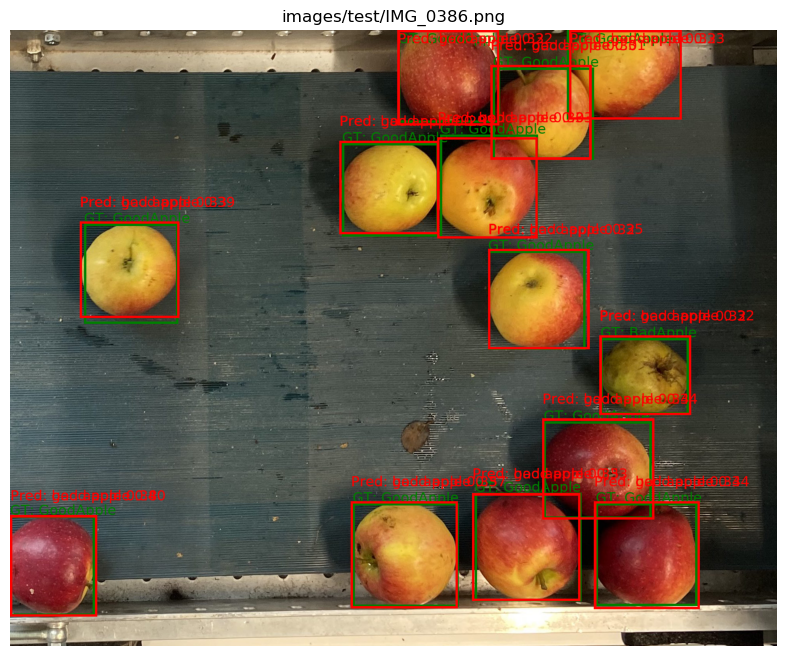

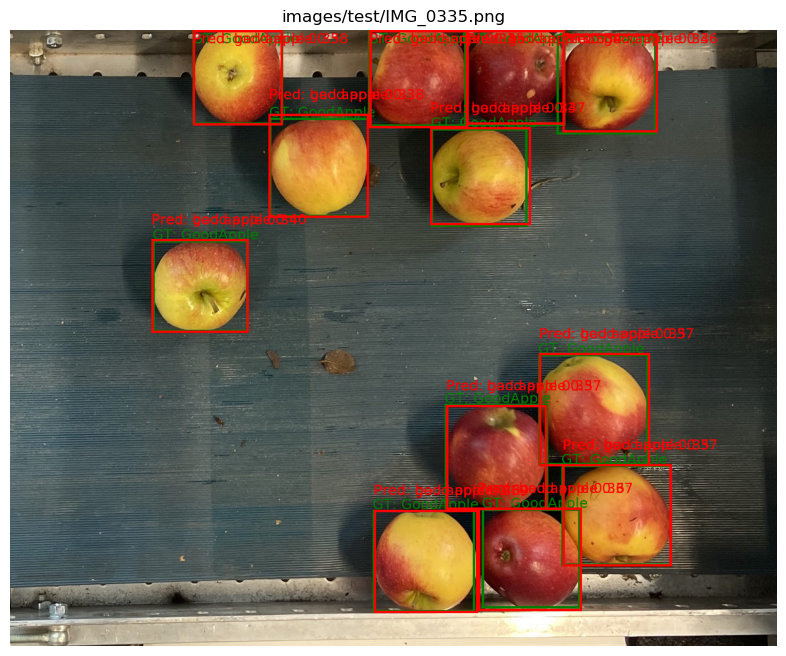

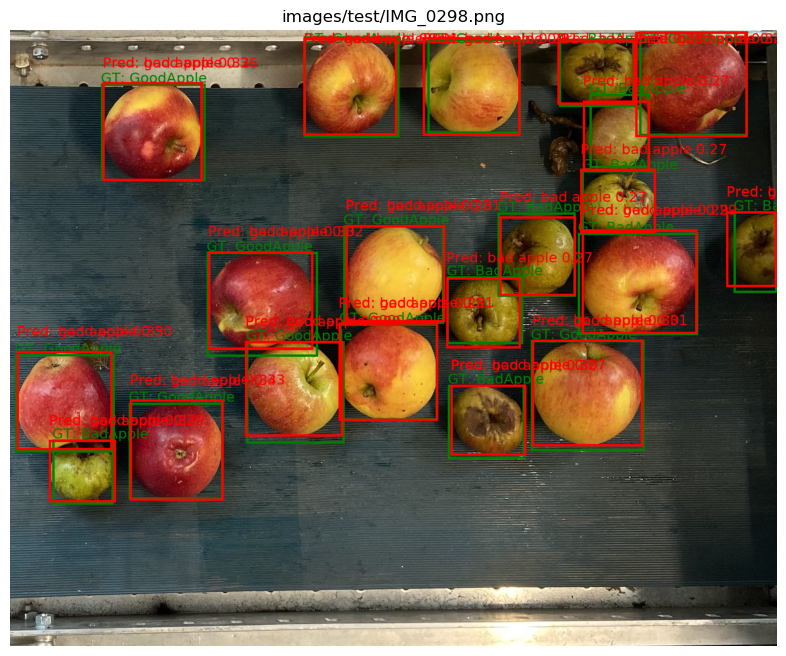

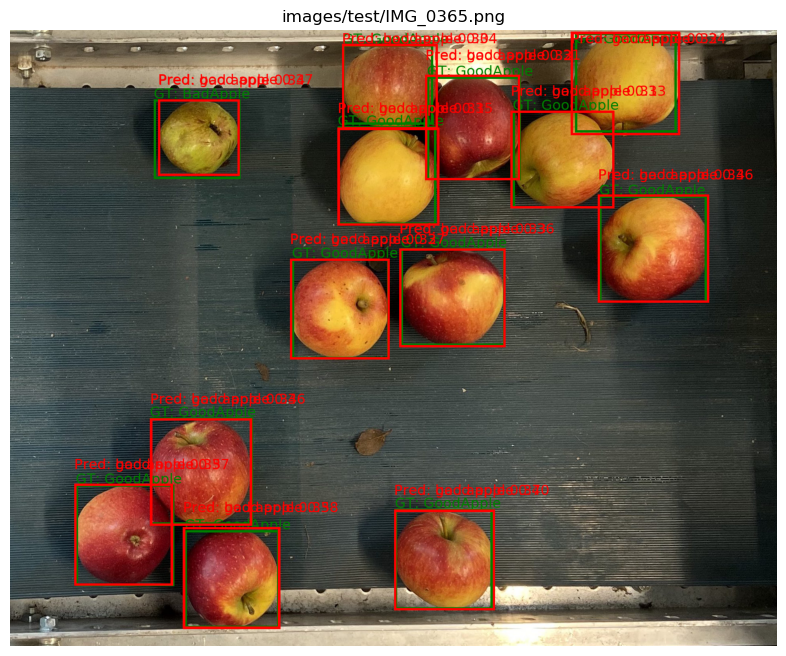

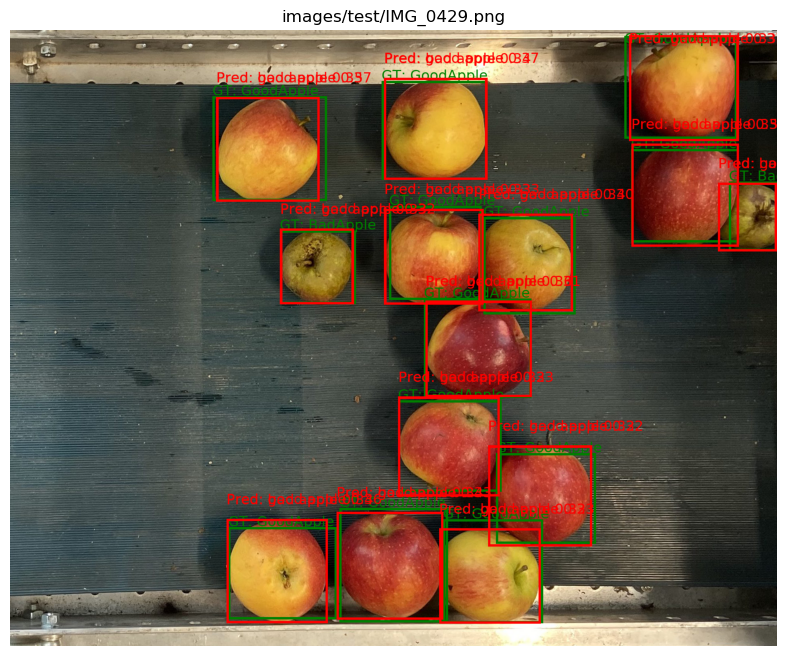

In [15]:
dataset = "apples"
dataset_root = DATA_ROOT / dataset 
# experiment = 'Experiment_1'
experiment = 'Experiment_2.1'

coco_json_path = PREDICTIONS_ROOT / experiment / "apples_test_mmgd_t_predictions.json"
gt_coco_json_path = DATA_ROOT / dataset / "annotations" / "instances_test.json"

show_coco_predictions(dataset_root, coco_json_path, gt_coco_json_path, scale= 3, max_images =5 )